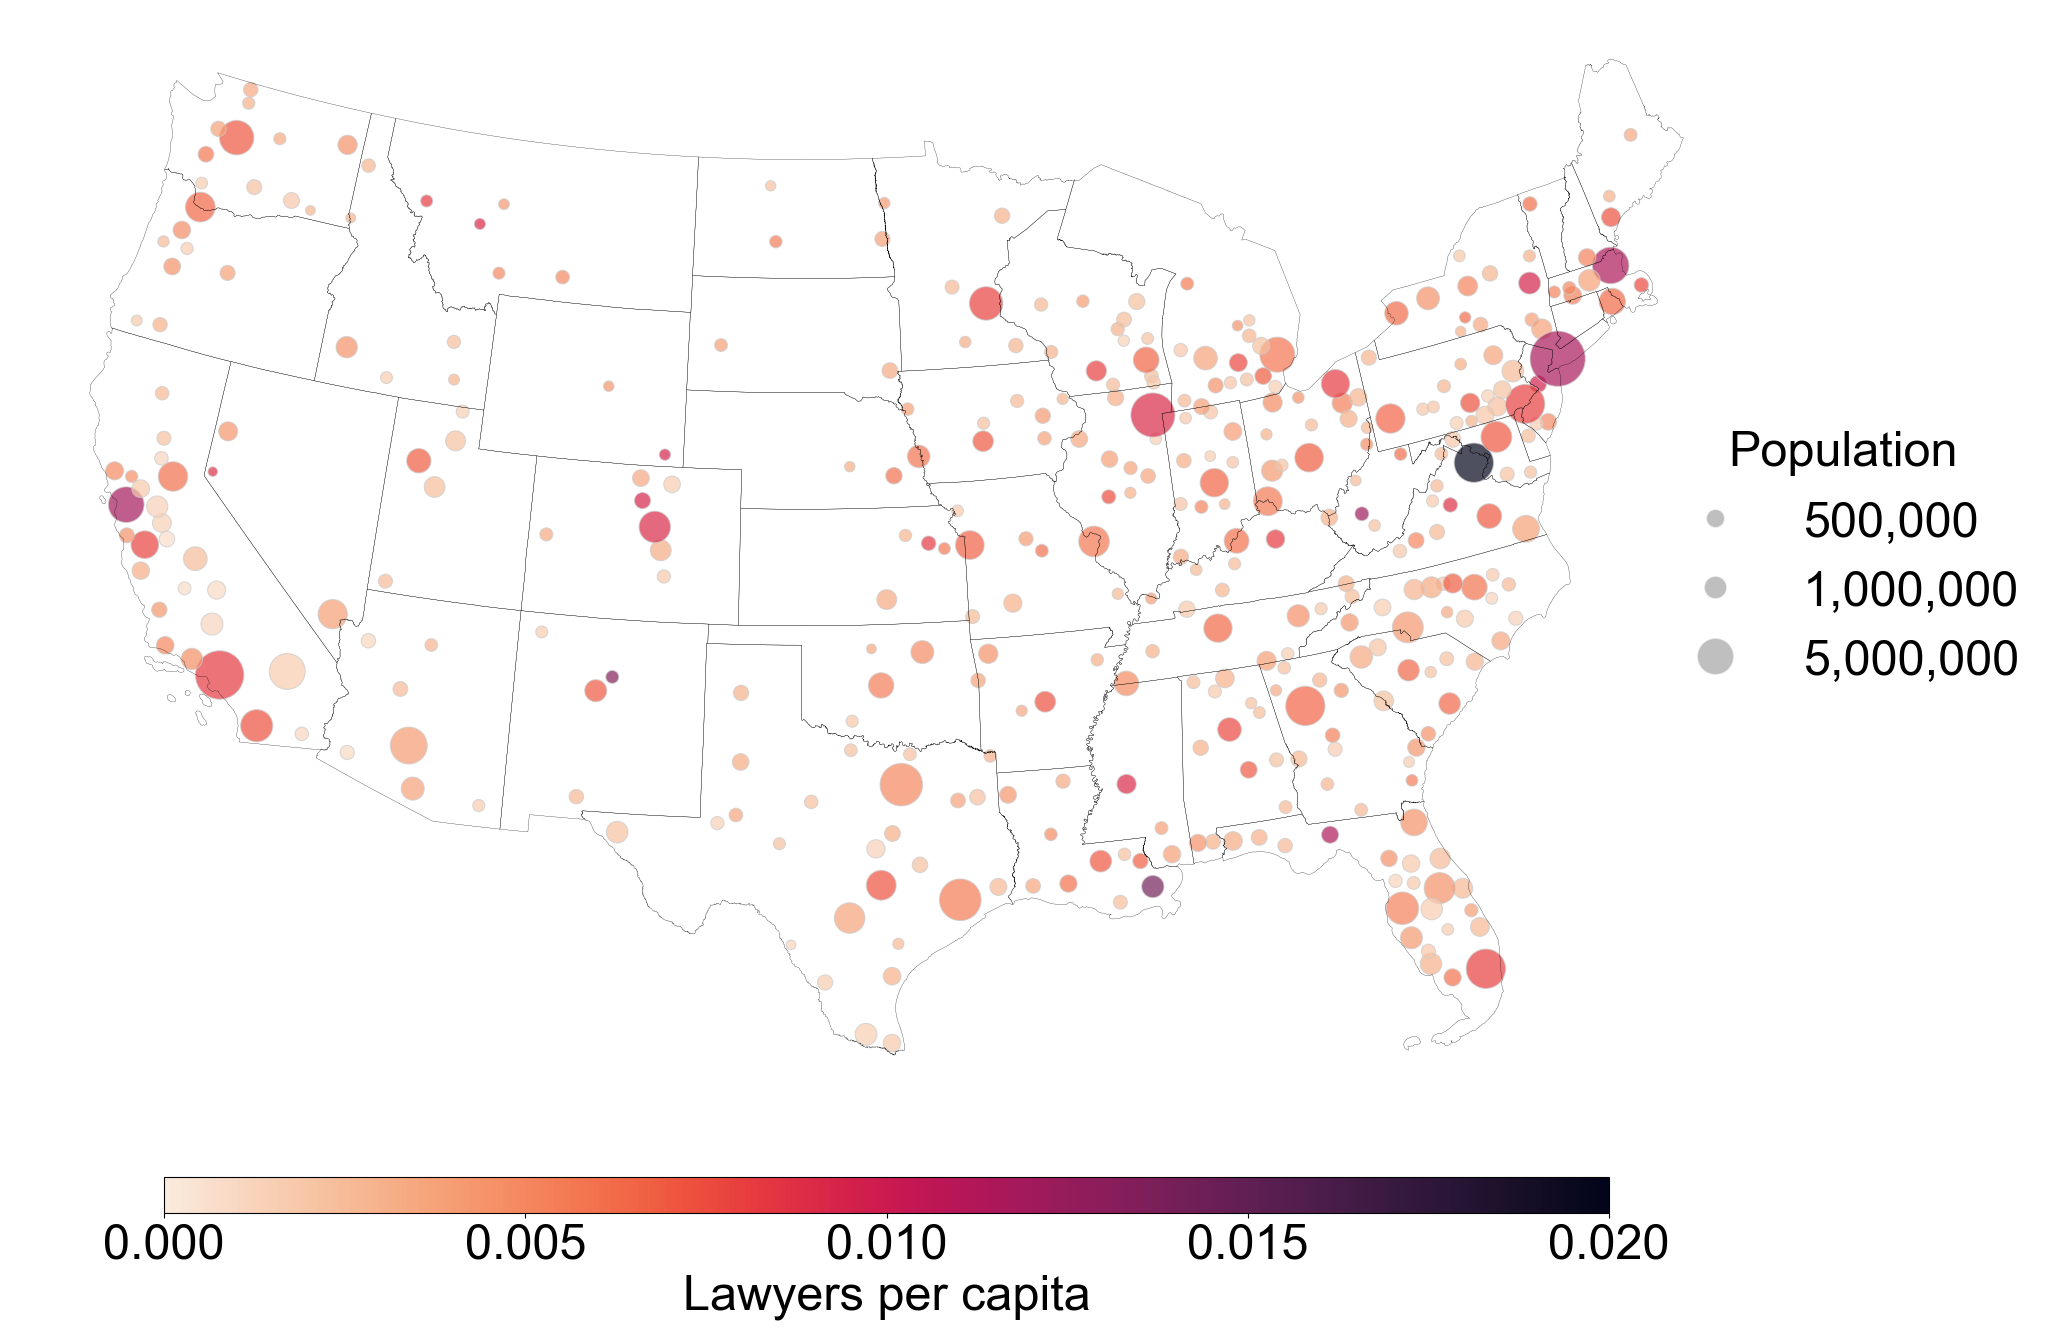

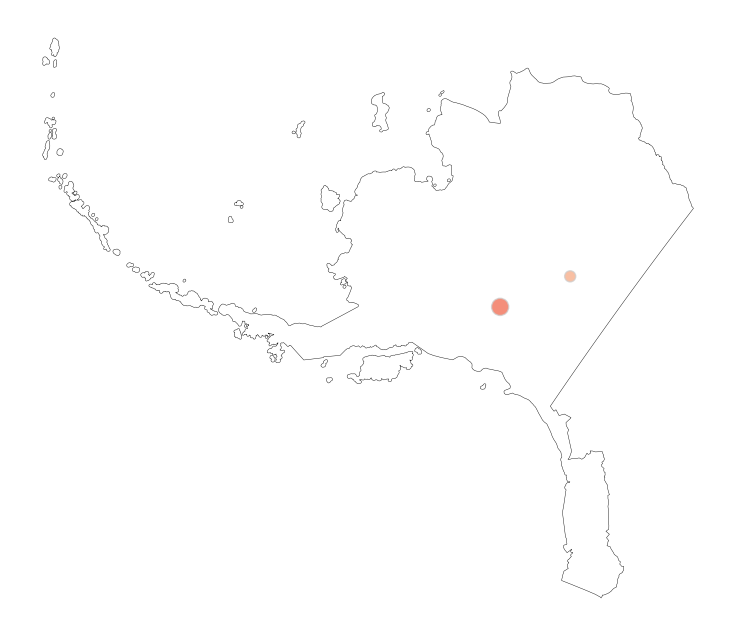

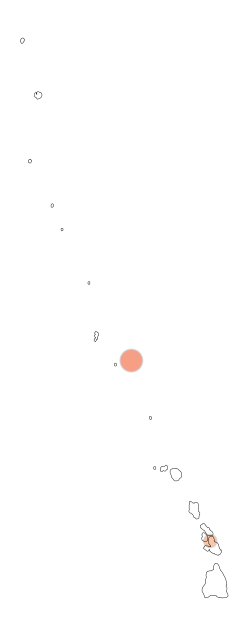

In [4]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from matplotlib.lines import Line2D
import numpy as np
from pathlib import Path

current_path = Path.cwd().resolve()
PROJECT_ROOT = next((p for p in [current_path, *current_path.parents] if (p / "Scripts").is_dir()), None)

if PROJECT_ROOT is None:
    raise FileNotFoundError("Run this notebook from within the repository.")
    
# Load data
# FIPS
fips_path = PROJECT_ROOT/"Data/Geography/FIPS/US states FIPS.csv"
df_fips = pd.read_csv(fips_path)
df_fips["FIPS Code"] = df_fips["FIPS Code"].astype(str).str.zfill(2)

# State
state_shapefile_path = PROJECT_ROOT/"Data/Geography/State_shapefile_2025/tl_2025_us_state.shp"
gdf_state = gpd.read_file(state_shapefile_path)
gdf_state = gdf_state.rename(columns={'NAME': 'State'})
gdf_state["STATEFP"] = gdf_state["STATEFP"].astype(str)
gdf_state = gdf_state[gdf_state["STATEFP"].isin(df_fips["FIPS Code"])].copy().reset_index(drop=True)

# MSAs
msa_shapefile_path = PROJECT_ROOT/"Data/Geography/CBSA_shapefile_2025/tl_2025_us_cbsa.shp"
gdf_msa = gpd.read_file(msa_shapefile_path)
gdf_msa = gdf_msa[gdf_msa["LSAD"] == 'M1'].reset_index(drop=True)
gdf_msa['State_Abbr'] = gdf_msa['NAME'].str[-2:]
gdf_msa = gdf_msa[gdf_msa['State_Abbr'].isin(df_fips['Postal Abbr.'])].copy()
gdf_msa["GEOID"] = gdf_msa["GEOID"].astype(str)
valid_name= gdf_msa["NAME"].astype(str).tolist()
valid_geoid= gdf_msa["GEOID"].astype(str).tolist()

# Population
pop_path = PROJECT_ROOT/"Data/Population Data/MSA Population/ACSDT1Y2024.B01003-Data.csv"
population_data = pd.read_csv(pop_path)
population_data = population_data[['GEO_ID', 'NAME', 'B01003_001E']].copy()
population_data.rename(columns={'GEO_ID': 'AREA', 'NAME': 'MSA', 'B01003_001E': 'Population'}, inplace=True)
population_data = population_data.iloc[1:].reset_index(drop=True)
population_data['AREA'] = population_data['AREA'].str[-5:]
population_data["AREA"] = population_data["AREA"].astype(str)
population_data["Population"] = pd.to_numeric(population_data["Population"], errors="coerce")
population_data = population_data[population_data["AREA"].isin(valid_geoid)]

# Lawyers
lawyers_path = PROJECT_ROOT/"Data/BrightData_Lawyers/BrightData_Lawyers_master.csv"
lawyers_data = pd.read_csv(lawyers_path)
lawyers_data = lawyers_data[['CBSA', 'MSA', 'n_lawyers']]
lawyers_data.rename(columns={'CBSA': 'AREA', 'n_lawyers': 'Total_Lawyers'}, inplace=True)
lawyers_data["AREA"] = lawyers_data["AREA"].astype('Int64').astype(str)
lawyers_data = lawyers_data[lawyers_data["AREA"].isin(valid_geoid)]

# Dataset to plot
lawyers_data = lawyers_data.merge(population_data[['AREA', 'Population']], on=['AREA'], how='left')
gdf = gdf_msa.merge(lawyers_data, left_on="GEOID", right_on="AREA", how="inner")
gdf["Lawyers_PerCapita"] = gdf["Total_Lawyers"] / gdf["Population"]
gdf["Pop_density"] = gdf["Population"] / (gdf["ALAND"] / 1000**2)

# Plotting
plt.rcParams.update({
    'font.size': 35,
    'lines.linewidth': 2,
    'font.family': 'arial',
    'mathtext.fontset': 'cm',
    'mathtext.default': 'rm',
    'mathtext.rm': 'arial',
})

gdf = gdf.to_crs(epsg=2163)
gdf_state = gdf_state.to_crs(epsg=2163)

variable = "Lawyers_PerCapita"
vmin = 0
vmax = max(gdf[variable].max(), 0.02)
cmap = sns.color_palette("rocket_r", as_cmap=True)

gdf['centroid'] = gdf.geometry.centroid
gdf_points = gdf.set_geometry('centroid')
size_factor = 9.3e1
gdf_points['marker_size'] = (gdf_points['Population'] / size_factor) ** 0.6

# Continental US
fig, ax = plt.subplots(figsize=(22, 14))
ax.axis('off')
cont_states = gdf_state[~gdf_state['STUSPS'].isin(['AK', 'HI'])]
cont_states.boundary.plot(ax=ax, color='black', linewidth=0.2)
cont_pts = gdf_points[~gdf_points['State_Abbr'].isin(['AK', 'HI'])]
cont_pts.plot(
    ax=ax,
    markersize=cont_pts['marker_size'],
    column=variable,
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
    edgecolor='0.8',
    linewidth=0.8,
    alpha=0.7
)
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm._A = []
cbar = fig.colorbar(sm, ax=ax, orientation="horizontal", fraction=0.03, pad=0.06, aspect=40)
cbar.set_label("Lawyers per capita")
cbar.ax.tick_params(labelsize=35)
cbar.set_ticks([0, 0.005, 0.010, 0.015, 0.020])

legend_pop_sizes = [5e5, 1e6, 5e6]
legend_markers = [(p / size_factor)**0.6 for p in legend_pop_sizes]
legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           label=f'{int(p):,}',
           markerfacecolor='grey',
           markersize=np.sqrt(area),
           alpha=0.5)
    for p, area in zip(legend_pop_sizes, legend_markers)
]
ax.legend(
    handles=legend_elements,
    title='Population',
    loc='center left',
    bbox_to_anchor=(0.92, 0.5),
    frameon=False,
    fontsize=35,
    title_fontsize=35
)
plt.subplots_adjust(left=0.02, right=0.88, bottom=0.12, top=0.98)
plt.savefig(PROJECT_ROOT/"Figures/Figure 1/Lawyers_USA_Map_Original.pdf", format="pdf")
plt.show()

# Alaska
fig, ax = plt.subplots(figsize=(10, 8))
ax.axis('off')
ak_state = gdf_state[gdf_state['STUSPS'] == 'AK']
ak_state.boundary.plot(ax=ax, color='black', linewidth=0.3)
ak_pts = gdf_points[gdf_points['State_Abbr'] == 'AK']
ak_pts.plot(
    ax=ax,
    markersize=ak_pts['marker_size'],
    column=variable,
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
    edgecolor='0.8',
    alpha=0.7
)
plt.show()

# Hawaii
fig, ax = plt.subplots(figsize=(10, 8))
ax.axis('off')
hi_state = gdf_state[gdf_state['STUSPS'] == 'HI']
hi_state.boundary.plot(ax=ax, color='black', linewidth=0.3)
hi_pts = gdf_points[gdf_points['State_Abbr'] == 'HI']
hi_pts.plot(
    ax=ax,
    markersize=hi_pts['marker_size'],
    column=variable,
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
    edgecolor='0.8',
    alpha=0.7
)
plt.show()


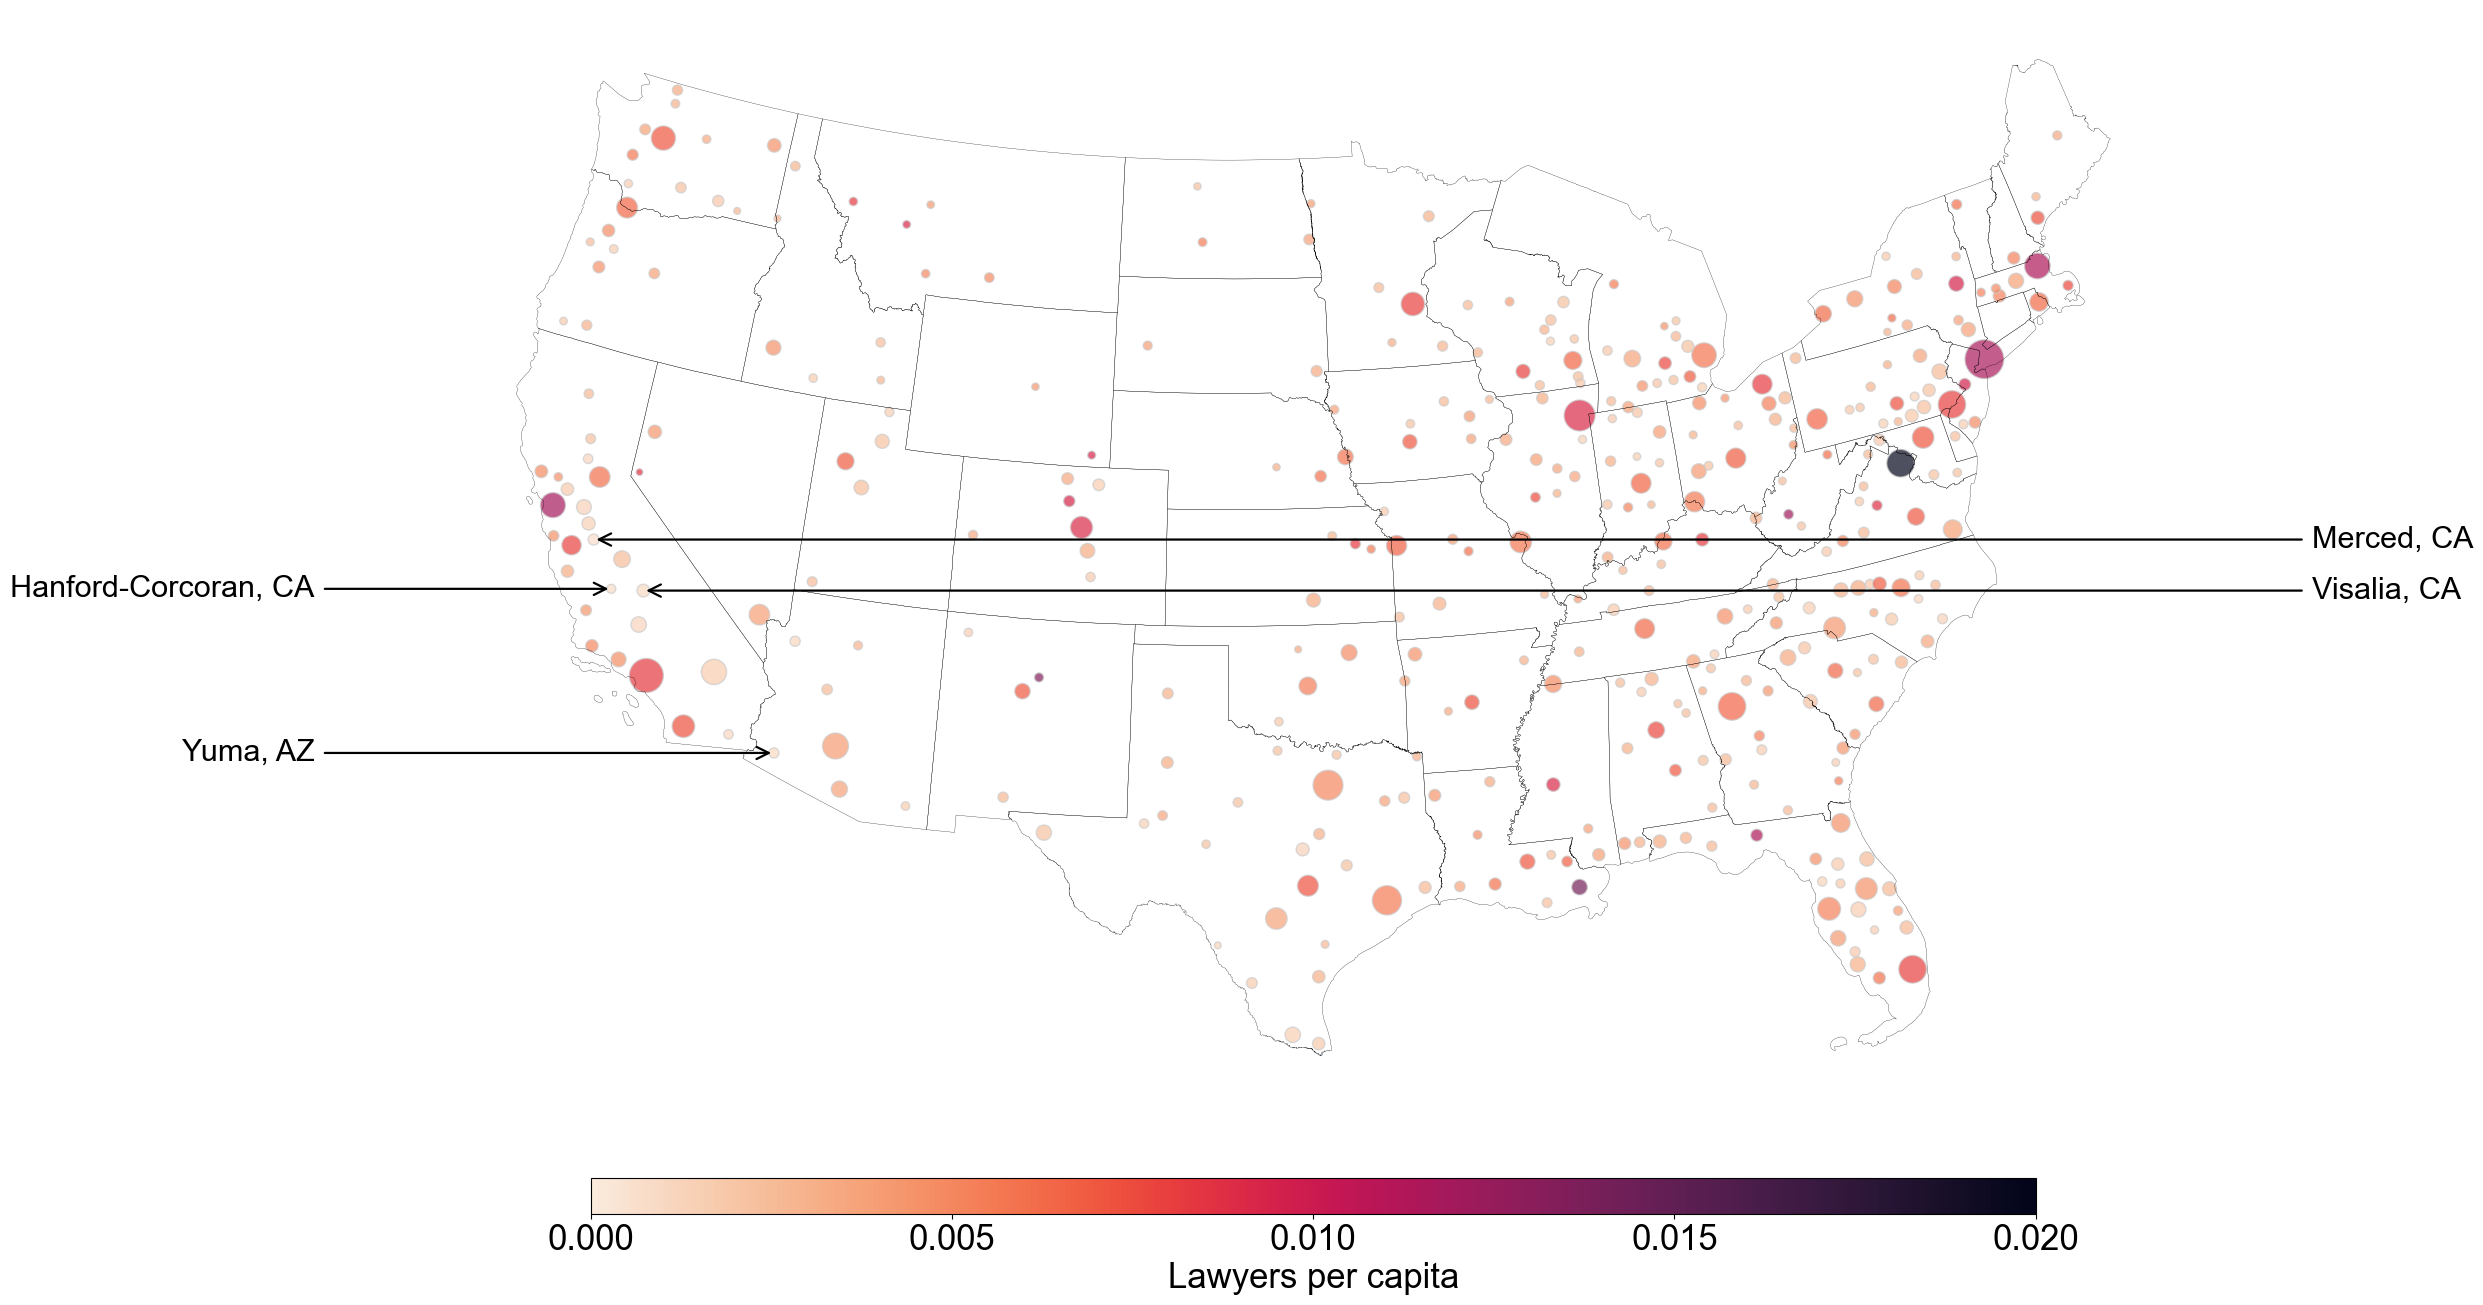

                      MSA  Lawyers_PerCapita
178           Visalia, CA           0.000984
278  Hanford-Corcoran, CA           0.000807
336            Merced, CA           0.000724
344              Yuma, AZ           0.000940


In [5]:
# Plotting
plt.rcParams.update({
    'font.size': 25,
    'lines.linewidth': 2,
    'font.family': 'arial',
    'mathtext.fontset': 'cm',
    'mathtext.default': 'rm',
    'mathtext.rm': 'arial',
})

gdf = gdf.to_crs(epsg=2163)
gdf_state = gdf_state.to_crs(epsg=2163)

variable = "Lawyers_PerCapita"
vmin = 0
vmax = max(gdf[variable].max(), 0.02)
cmap = sns.color_palette("rocket_r", as_cmap=True)

gdf['centroid'] = gdf.geometry.centroid
gdf_points = gdf.set_geometry('centroid')
size_factor = 3e2
gdf_points['marker_size'] = (gdf_points['Population'] / size_factor) ** 0.6

# Continental US
fig, ax = plt.subplots(figsize=(22, 14))
ax.axis('off')
cont_states = gdf_state[~gdf_state['STUSPS'].isin(['AK', 'HI'])]
cont_states.boundary.plot(ax=ax, color='black', linewidth=0.2)
cont_pts = gdf_points[~gdf_points['State_Abbr'].isin(['AK', 'HI'])]
cont_pts = cont_pts.copy()
cont_pts.plot(
    ax=ax,
    markersize=cont_pts['marker_size'],
    column=variable,
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
    edgecolor='0.8',
    alpha=0.7
)

# Areas to annotate 
gdf_desert = gdf[gdf["Lawyers_PerCapita"] <= 1/1000].copy()
gdf_desert["AREA"] = gdf_desert["AREA"].astype(int)
areas_to_label = gdf_desert["AREA"].values

cont_pts = cont_pts.copy()
cont_pts["AREA"] = cont_pts["AREA"].astype(int)

gdf_labels = cont_pts[cont_pts["AREA"].isin(areas_to_label)].copy()

gdf_labels["AREA"] = pd.Categorical(
    gdf_labels["AREA"],
    categories=areas_to_label,
    ordered=True
)
gdf_labels = gdf_labels.sort_values("AREA")

gdf_labels["centroid_geom"] = gdf_labels.geometry.centroid

# map bounds
x_min, x_max = ax.get_xlim()

left_x = x_min - 3.5e5
right_x = x_max + 3.5e5

for i, row in enumerate(gdf_labels.itertuples()):
    cx = row.centroid_geom.x
    cy = row.centroid_geom.y
    
    if i % 2 == 0:
        lx = right_x
        ha = 'left'
    else:
        lx = left_x
        ha = 'right'

    ax.annotate(
        text=row.NAME,
        xy=(cx, cy),     
        xytext=(lx, cy),  
        fontsize=22,
        ha=ha,
        va='center',
        color='black',
        arrowprops=dict(
            arrowstyle='->',
            color='black',
            lw=1.6
        ),
        bbox=dict(
            boxstyle='round,pad=0.25',
            fc='white',
            ec='none',
            alpha=0.85
        )
    )

norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm._A = []
cbar = fig.colorbar(sm, ax=ax, orientation="horizontal", fraction=0.03, pad=0.06, aspect=40)
cbar.set_label("Lawyers per capita")
cbar.ax.tick_params(labelsize=25)
cbar.set_ticks([0, 0.005, 0.010, 0.015, 0.020])

plt.subplots_adjust(left=0.02, right=0.88, bottom=0.12, top=0.98)
plt.savefig(PROJECT_ROOT/"Figures/Figure 1/Lawyers_USA_Map_Legal_Deserts.pdf", format="pdf")
plt.show()

print(gdf_desert[["MSA","Lawyers_PerCapita"]])